In [8]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr

import zipfile

with zipfile.ZipFile("C:\\Users\\User\\Desktop\\Downloads\\test.csv.zip", 'r') as z:
    z.extractall("C:\\Users\\User\\")

df = pd.read_csv("C:\\Users\\User\\Desktop\\Downloads\\test.csv.zip")
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  object 
 3   Customer Type                      25976 non-null  object 
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  object 
 6   Class                              25976 non-null  object 
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int

Unnamed: 0                            0
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0


In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: Index(['Unnamed: 0', 'id', 'Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes',
       'Arrival Delay in Minutes'],
      dtype='object')
Categorical: Index(['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction'], dtype='object')


In [10]:
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
df = df.dropna()

#### Task 1: Compute Pearson and Spearman Correlations
1.Select all numeric feature pairs in the dataset.

2.Compute the Pearson correlation matrix using pandas or scipy.

3.Compute the Spearman correlation matrix for the same pairs.

4.Create a summary table that shows, for each pair, both the Pearson r and the Spearman ρ, along with their p-values.

5.In a markdown cell, answer:

- Which pairs show the strongest linear relationships?
- Are there any pairs where Pearson and Spearman disagree noticeably? What might cause that?

In [14]:
pearson_corr = df[numeric_cols].corr(method='pearson')
spearman_corr = df[numeric_cols].corr(method='spearman')

print(pearson_corr)
print(spearman_corr)

                                   Unnamed: 0        id       Age  \
Unnamed: 0                           1.000000  0.006946 -0.007964   
id                                   0.006946  1.000000  0.010211   
Age                                 -0.007964  0.010211  1.000000   
Flight Distance                     -0.002470  0.095335  0.099409   
Inflight wifi service               -0.003085 -0.030303  0.009242   
Departure/Arrival time convenient   -0.003962 -0.002502  0.032449   
Ease of Online booking              -0.002011  0.010389  0.013565   
Gate location                       -0.001360  0.001843  0.003308   
Food and drink                      -0.010858 -0.006789  0.023841   
Online boarding                     -0.000254  0.055767  0.202058   
Seat comfort                        -0.005602  0.049212  0.154507   
Inflight entertainment              -0.012927 -0.001078  0.068998   
On-board service                     0.001180  0.056544  0.054977   
Leg room service                  

In [15]:
results = []

for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        col1 = numeric_cols[i]
        col2 = numeric_cols[j]

        x = df[col1]
        y = df[col2]

        pearson_r, pearson_p = pearsonr(x, y)
        spearman_rho, spearman_p = spearmanr(x, y)

        results.append({
            "Feature 1": col1,
            "Feature 2": col2,
            "Pearson r": pearson_r,
            "Pearson p": pearson_p,
            "Spearman ρ": spearman_rho,
            "Spearman p": spearman_p
        })

summary_df = pd.DataFrame(results)
summary_df

,Feature 1,Feature 2,Pearson r,Pearson p,Spearman ρ,Spearman p
0,Unnamed: 0,id,0.006946,2.629399e-01,0.006889,2.668732e-01
1,Unnamed: 0,Age,-0.007964,1.992917e-01,-0.008206,1.859765e-01
2,Unnamed: 0,Flight Distance,-0.002470,6.905498e-01,-0.002322,7.082564e-01
3,Unnamed: 0,Inflight wifi service,-0.003085,6.190342e-01,-0.003532,5.692187e-01
4,Unnamed: 0,Departure/Arrival time convenient,-0.003962,5.230779e-01,-0.003789,5.413952e-01
...,...,...,...,...,...,...
185,Inflight service,Departure Delay in Minutes,-0.052823,1.608109e-17,-0.044089,1.168946e-12
186,Inflight service,Arrival Delay in Minutes,-0.062421,7.515699e-24,-0.065203,7.020627e-26
187,Cleanliness,Departure Delay in Minutes,-0.016378,8.296683e-03,-0.023585,1.437690e-04
188,Cleanliness,Arrival Delay in Minutes,-0.019700,1.497143e-03,-0.031077,5.453797e-07


In [16]:
summary_df["abs_pearson"] = summary_df["Pearson r"].abs()

strongest = summary_df.sort_values(by="abs_pearson", ascending=False)
strongest.head()

,Feature 1,Feature 2,Pearson r,Pearson p,Spearman ρ,Spearman p,abs_pearson
189,Departure Delay in Minutes,Arrival Delay in Minutes,0.956855,0.0,0.737230,0.0,0.956855
71,Inflight wifi service,Ease of Online booking,0.710684,0.0,0.707514,0.0,0.710684
159,Inflight entertainment,Cleanliness,0.695269,0.0,0.682770,0.0,0.695269
151,Seat comfort,Cleanliness,0.683924,0.0,0.671114,0.0,0.683924
132,Food and drink,Cleanliness,0.659253,0.0,0.647138,0.0,0.659253


1. Strongest linear relationships:
The pairs with the highest absolute Pearson correlation (|r| close to 1) show the strongest linear relationships. These variables move together in a linear way.

2. Differences between Pearson and Spearman:
Yes, some pairs show differences between Pearson and Spearman correlations.

Pearson measures linear relationships
Spearman measures monotonic relationships (not necessarily linear)

If Spearman is high but Pearson is lower, it suggests a non-linear but monotonic relationship.

#### Task 2: Build a Correlation Heatmap
1.Using seaborn.heatmap, create an annotated heatmap of the Pearson correlation matrix.

- Use a diverging colormap (e.g., coolwarm or RdBu_r) centered at zero.
  
- Annotate each cell with the correlation value rounded to two decimal places.

- Mask the upper triangle so the matrix is easier to read.

2.Create a second heatmap for the Spearman matrix using the same layout.

3.In a markdown cell, compare the two heatmaps:

- Where do they agree?
  
- Where do they differ, and what does that tell you about the shape of those relationships?

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [18]:
# Pearson və Spearman matrix
pearson_corr = df[numeric_cols].corr(method='pearson')
spearman_corr = df[numeric_cols].corr(method='spearman')

In [19]:
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

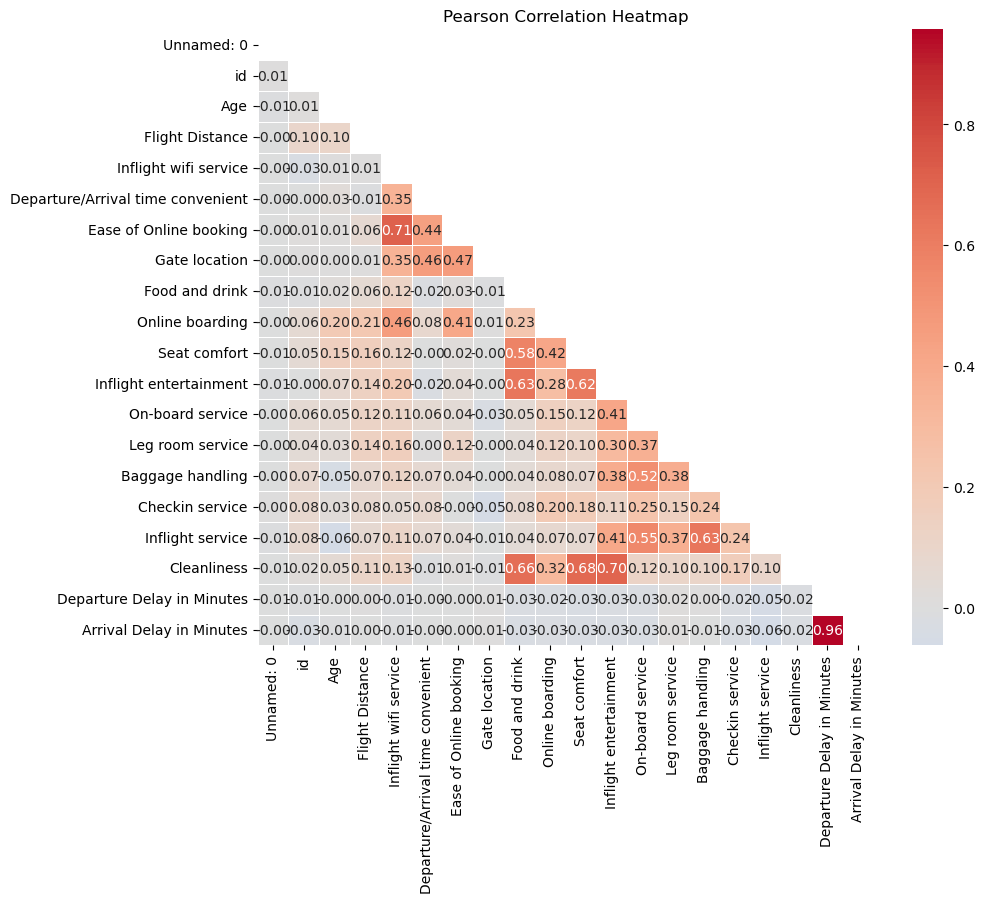

In [20]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    pearson_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap")
plt.show()

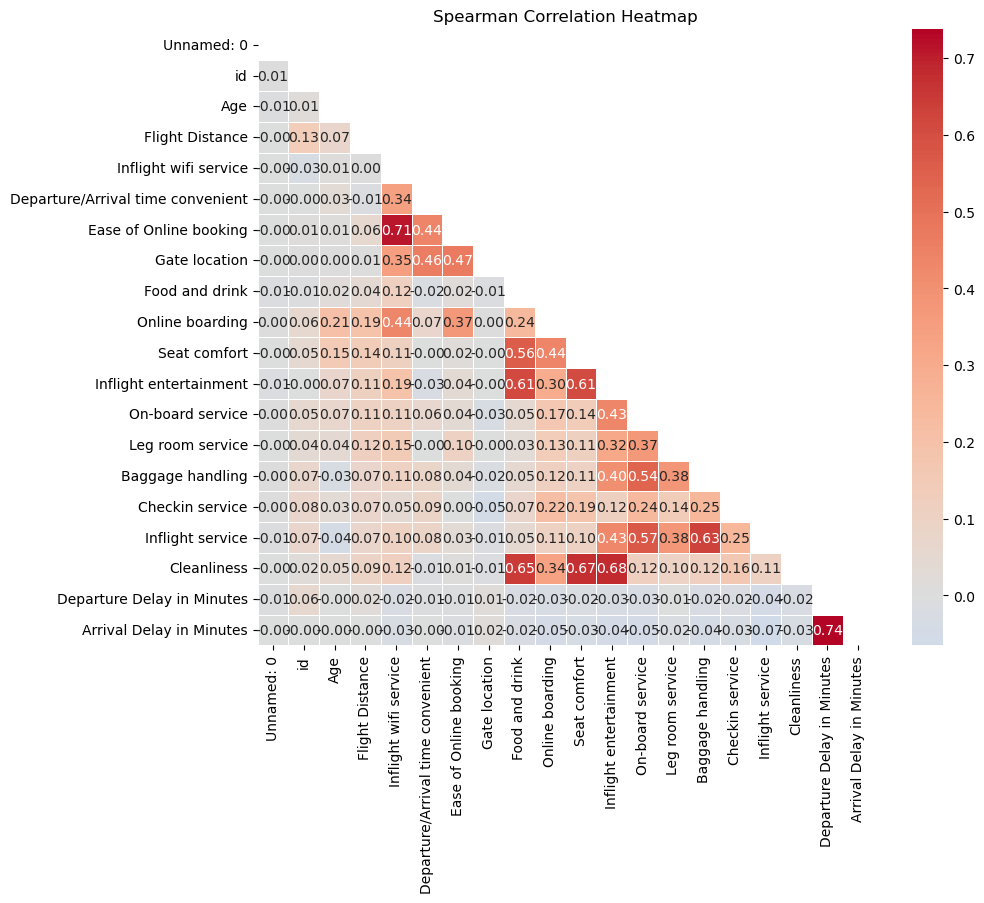

In [21]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    spearman_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Spearman Correlation Heatmap")
plt.show()

1. Where they agree:

Most variable pairs have similar colors and values in both heatmaps. This means the relationships are consistent and likely linear. Strong positive or negative correlations appear in both methods.

3. Where they differ:

Some pairs show stronger correlation in Spearman than in Pearson. This suggests a monotonic but non-linear relationship (e.g., curved relationship).

If Pearson is higher than Spearman, it may indicate that the relationship is more linear or affected by outliers.

3. Interpretation:

Pearson ≈ Spearman → linear relationship

Spearman > Pearson → non-linear but monotonic

Differences → relationship shape is not purely linear

#### Task 3: Scatterplot Analysis of Key Pairs

1.Pick the three feature pairs with the highest absolute Pearson correlation.

2.For each pair, produce a scatterplot with:

- A regression line (use seaborn.regplot or seaborn.lmplot).

- Points colored by a categorical grouping variable (e.g., species, sex, or day).

3.In a markdown cell, discuss:

- Does the regression line capture the actual pattern well?

- Do subgroups show different slopes or intercepts?

In [22]:
summary_df["abs_pearson"] = summary_df["Pearson r"].abs()

top3 = summary_df.sort_values(by="abs_pearson", ascending=False).head(3)

top3

,Feature 1,Feature 2,Pearson r,Pearson p,Spearman ρ,Spearman p,abs_pearson
189,Departure Delay in Minutes,Arrival Delay in Minutes,0.956855,0.0,0.737230,0.0,0.956855
71,Inflight wifi service,Ease of Online booking,0.710684,0.0,0.707514,0.0,0.710684
159,Inflight entertainment,Cleanliness,0.695269,0.0,0.682770,0.0,0.695269


In [23]:
print(categorical_cols)

Index(['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction'], dtype='object')


In [25]:
hue_col = categorical_cols[0]

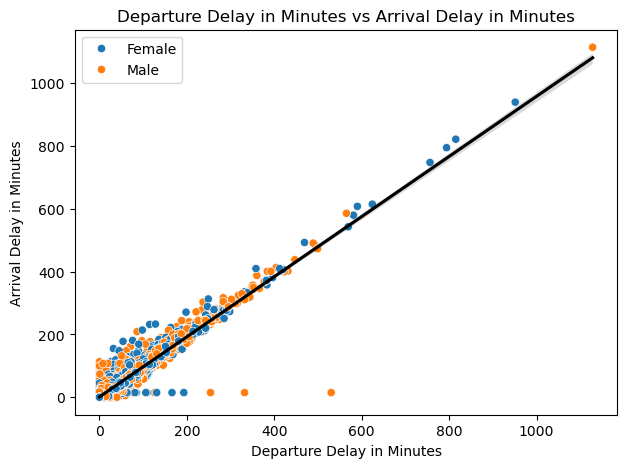

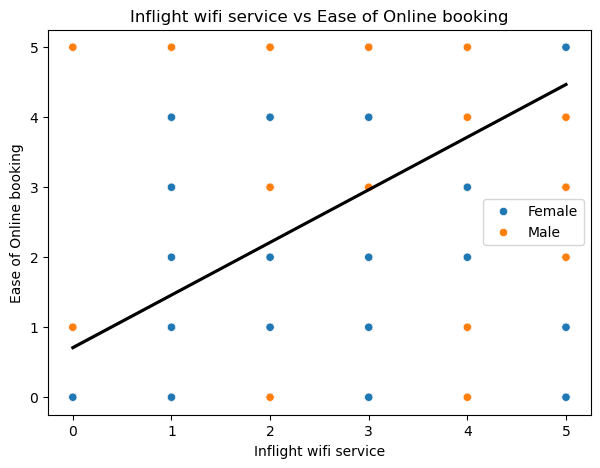

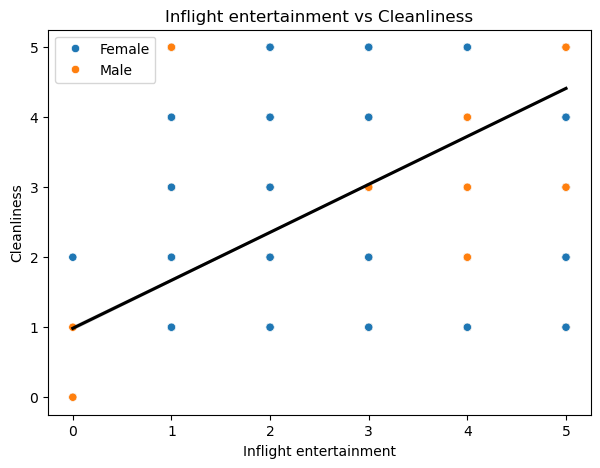

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

for i, row in top3.iterrows():
    x_col = row["Feature 1"]
    y_col = row["Feature 2"]

    plt.figure(figsize=(7,5))

    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue_col
    )

    sns.regplot(
        data=df,
        x=x_col,
        y=y_col,
        scatter=False,
        color="black"
    )

    plt.title(f"{x_col} vs {y_col}")
    plt.legend()
    plt.show()

1. Does the regression line capture the actual pattern well?
In some feature pairs, the regression line fits the data well, with points closely aligned around the line. This indicates a strong linear relationship.

In other pairs, the data points may be more scattered or show a curved pattern, suggesting that the relationship is not strictly linear and the regression line does not fully capture it.

2. Do subgroups show different slopes or intercepts?
Yes, when data points are colored by a categorical variable, different subgroups sometimes form distinct clusters.

Some groups show different slopes, indicating that the relationship between variables changes across groups.
Other groups may have similar slopes but different intercepts, meaning they follow parallel trends but start at different levels.

This suggests that the relationship between variables may depend on the subgroup.